# 디지털 서비스 교역에서 거리의 효과는 약해졌는가 — 재현 노트북

`paper.md`가 인용하는 모든 수치와 그림 하나를 이 노트북 하나로 만든다. 위에서 아래로 실행하면
`img/`의 그림이 갱신되고, 마지막 절이 본문의 수치를 하나씩 대조해 어긋나면 `AssertionError`로
멈춘다. 중간 산출물을 파일로 남기지 않는다. 전체 실행에 몇 시간이 걸린다. 디지털 범주와 비교 범주의 부분표본 추정이 가장 오래 걸린다.

필요한 것

- 이 저장소의 `data/processed/svcdb.duckdb` (BaTIS 2025년 12월판)
- `data/external/cepii-gravity/Gravity_csv_V202211.zip` (CEPII Gravity V202211). 압축을 푼 CSV가
  `data/interim/cepii-gravity/`에 없으면 이 노트북이 푼다
- 파이썬 패키지 `pyfixest` (0.60.0에서 실행했다)

## §0. 설정

경로, 그림 표준, 문서 전체에서 쓰는 상수를 둔다. 분석 기간은 2010\~2023년이다. 2010년에 Eurostat
국제서비스교역통계가 보고치로 들어오면서 보고표본의 관측 수가 한 해에 몇 배로 늘어나고, 2024년은
보고가 덜 들어왔다(§2에서 확인한다). 범주는 EBOPS 2010의 대분류 여덟이다. 운송과 여행을 묶어 비교
범주로 두고, 보험·연금, 금융, 지식재산권 사용료, 통신·컴퓨터·정보, 기타 사업, 개인·문화·여가
여섯을 디지털 전달 가능 서비스(이하 디지털 서비스)로 둔다(IMF et al., 2023).

추정은 모두 PPML이고 표준오차는 나라쌍(수출국과 수입국의 순서쌍) 군집이다. 고정효과 제거는 LSMR로 한다. 기본값인
교대 투영(MAP)이 두 범주의 부분표본을 추정한 식 하나에서 10만 회 안에 수렴하지 않았기 때문이다. 수렴한
식에서는 두 방법의 계수가 소수 다섯째 자리까지 같았다(2026-09-24 확인).

In [1]:
import json, time, warnings, zipfile
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyfixest as pf
from IPython.display import Image, display

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

HERE = Path.cwd()
if not (HERE / "paper.md").exists() and (HERE / "research" / "03-digital-distance").exists():
    HERE = HERE / "research" / "03-digital-distance"
assert (HERE / "paper.md").exists(), f"연구 폴더에서 실행한다 (지금: {HERE})"
ROOT = HERE.parents[1]
DB = ROOT / "data" / "processed" / "svcdb.duckdb"
GZIP = ROOT / "data" / "external" / "cepii-gravity" / "Gravity_csv_V202211.zip"
GCSV = ROOT / "data" / "interim" / "cepii-gravity" / "Gravity_V202211.csv"
IMG = HERE / "img"
IMG.mkdir(exist_ok=True)
assert DB.exists(), f"서비스 교역 DB가 없다: {DB}"
assert GZIP.exists() or GCSV.exists(), f"CEPII Gravity가 없다: {GZIP}"

plt.rcParams.update({
    "font.family": "Malgun Gothic", "axes.unicode_minus": False,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "0.87", "grid.linewidth": 0.8,
    "font.size": 9, "axes.titlesize": 10, "legend.frameon": False,
})
pd.set_option("display.width", 170)

Y0, Y1 = 2010, 2023
BASE = ["SC", "SD"]
DIGITAL = ["SF", "SG", "SH", "SI", "SJ", "SK"]
ITEMS = BASE + DIGITAL
NAME = {"SC": "운송", "SD": "여행", "SF": "보험·연금", "SG": "금융", "SH": "지식재산권 사용료",
        "SI": "통신·컴퓨터·정보", "SJ": "기타 사업", "SK": "개인·문화·여가"}
EU27 = {"AUT", "BEL", "BGR", "HRV", "CYP", "CZE", "DNK", "EST", "FIN", "FRA", "DEU", "GRC", "HUN",
        "IRL", "ITA", "LVA", "LTU", "LUX", "MLT", "NLD", "POL", "PRT", "ROU", "SVK", "SVN", "ESP", "SWE"}
GCHINA = {"CHN", "HKG", "MAC", "TWN"}
S: dict = {}

DM = pf.LsmrDemeaner(fixef_maxiter=100_000, fixef_atol=1e-10, fixef_btol=1e-10)


def ppml(d, rhs, fe):
    return pf.fepois(f"v ~ {rhs} | {fe}", data=d, vcov={"CRV1": "pair"},
                     demeaner=DM, iwls_maxiter=100)


def coef(m, var):
    t = m.tidy().loc[var]
    return {"b": float(t["Estimate"]), "se": float(t["Std. Error"]),
            "p": float(t["Pr(>|t|)"]), "n": int(m._N)}


def r(x, n=3):
    return None if x is None or (isinstance(x, float) and np.isnan(x)) else round(float(x), n)

## §1. 거리와 통제변수

CEPII Gravity V202211에서 거리와 세 통제변수를 가져온다(III.2절). 거리는 인구 가중 조화평균
거리(`distw_harmonic`)이고, 강건성 확인을 위해 대표 도시 간 거리(`dist`)와 수도 간 거리(`distcap`)도
함께 둔다. 통제변수는 국경 인접(`contig`), 공용어(`comlang_off`), 식민 관계(`col_dep_ever`)이며
BaTIS가 보고치 없는 교역을 추정할 때 쓴 교역비용 변수와 같다(OECD and WTO, 2025b).

BaTIS 코드는 Gravity의 iso3와 맞춘다. Gravity는 국경이 바뀐 나라에 `DEU.2` 꼴의 번호를 붙이므로
`country_id`로 맞추면 여덟 나라가 빠진다. 옛 네덜란드령 안틸레스(`ANT_F`)는 `ANT`로 맞추고,
Gravity에 없는 코소보(`XKV`)는 뺀다. 시간에 따라 변하지 않는 변수이므로 2010\~2021년 가운데 두
나라가 모두 존재한 가장 늦은 해의 값을 두 나라 사이에 하나 붙인다. Gravity가 2021년에서 끝나도
2022\~2023년 관측에 같은 값을 쓸 수 있는 이유다.

In [2]:
if not GCSV.exists():
    GCSV.parent.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(GZIP) as z:
        z.extract(GCSV.name, GCSV.parent)

con = duckdb.connect()
con.execute(f"ATTACH '{DB.as_posix()}' AS s (READ_ONLY)")
S["edition"] = con.execute("SELECT DISTINCT edition FROM s.fact_batis").fetchall()
assert S["edition"] == [("2025-12",)], S["edition"]

GV = ["distw_harmonic", "dist", "distcap", "contig", "comlang_off", "col_dep_ever"]
con.execute(f"""
CREATE TEMP TABLE g_pair AS
SELECT iso3_o, iso3_d, {", ".join(f'arg_max({v}, "year") AS {v}' for v in GV)}
FROM read_csv('{GCSV.as_posix()}', auto_detect=true, sample_size=-1)
WHERE "year" BETWEEN {Y0} AND 2021 AND country_exists_o = 1 AND country_exists_d = 1
  AND iso3_o <> iso3_d
GROUP BY 1, 2
""")
S["g_pairs"] = con.execute("SELECT count(*) FROM g_pair").fetchone()[0]
print("Gravity 나라쌍:", S["g_pairs"])

Gravity 나라쌍: 55458


## §2. 보고표본

나라쌍 $(i, j)$의 관측은 $i$의 수출 보고(보고국 $i$, 상대국 $j$) 또는 $j$의 수입 보고(보고국 $j$,
상대국 $i$) 가운데 하나라도 방법론 코드가 보고치(`R_`로 시작)이면 보고표본에 넣는다(III.1절).
이 절의 표본 기술은 두 보고를 화해시킨 균형치로 하고, 추정에 쓰는 값은 §3에서 보고치로 바꾼다.
추정으로 채운 값도 지우지 않고 `obs = False`로 남겨 III.1절의 금액 비중을 구할 때 분모에 쓴다. 집계 코드와 잔여 코드(`WXD`)는 뺀다.

이 절은 기간을 2010\~2023년으로 정한 근거(2009\~2010년의 보고 급증과 2024년의 미완결)와 III.1절의
범주별 보고 범위를 함께 계산한다.

In [3]:
# 기간 선택의 근거: 총서비스의 관측 흐름 수와 2010년에 새로 들어온 출처
yr_obs = con.execute("""
WITH ind AS (SELECT code FROM s.dim_area WHERE NOT is_aggregate AND code <> 'WXD'),
b AS (SELECT f.reporter, f.partner, f.flow, f.year, f.methodology
      FROM s.fact_batis f JOIN s.dim_methodology m ON f.methodology = m.code
      WHERE m.mclass = 'reported' AND f.item_code = 'S'
        AND f.reporter IN (SELECT code FROM ind) AND f.partner IN (SELECT code FROM ind))
SELECT year, count(DISTINCT CASE WHEN flow = 'EXP' THEN reporter || '>' || partner
                                 ELSE partner || '>' || reporter END) AS n
FROM b GROUP BY 1 ORDER BY 1
""").df().set_index("year").n
src10 = con.execute("""
SELECT methodology, count(*) n FROM s.fact_batis
WHERE item_code = 'S' AND year = 2010
  AND methodology IN (SELECT code FROM s.dim_methodology WHERE mclass = 'reported')
  AND reporter NOT IN (SELECT code FROM s.dim_area WHERE is_aggregate OR code = 'WXD')
  AND partner  NOT IN (SELECT code FROM s.dim_area WHERE is_aggregate OR code = 'WXD')
GROUP BY 1 ORDER BY 2 DESC""").df()
S["S_obs_2009"], S["S_obs_2010"] = int(yr_obs[2009]), int(yr_obs[2010])
S["S_obs_2023"], S["S_obs_2024"] = int(yr_obs[2023]), int(yr_obs[2024])
S["S_2010_eu_its_share"] = r(100 * src10.set_index("methodology").n.get("R_EU_ITS", 0) / src10.n.sum(), 1)
# 서비스 수출에서 디지털 여섯 범주와 운송·여행이 차지하는 비중(I장). 추정 칸을 포함한 개별 경제 사이 균형치다
mix = con.execute(f"""
WITH ind AS (SELECT code FROM s.dim_area WHERE NOT is_aggregate AND code <> 'WXD')
SELECT year, item_code, sum(balanced_value) AS v FROM s.fact_batis
WHERE flow = 'EXP' AND year IN ({Y0}, {Y1}) AND item_code IN ('S', {", ".join(f"'{x}'" for x in ITEMS)})
  AND reporter IN (SELECT code FROM ind) AND partner IN (SELECT code FROM ind)
GROUP BY 1, 2""").df().pivot(index="year", columns="item_code", values="v")
S["mix"] = {str(y): {"digital": r(100 * mix.loc[y, DIGITAL].sum() / mix.loc[y, "S"], 1),
                     "base": r(100 * mix.loc[y, BASE].sum() / mix.loc[y, "S"], 1),
                     "SI": r(100 * mix.loc[y, "SI"] / mix.loc[y, "S"], 1)} for y in (Y0, Y1)}
print(S["mix"])
# 코소보가 포함된 관측 흐름의 비중(III.2절). Gravity에 없어 분석에서 빠진다.
xkv = con.execute(f"""
WITH ind AS (SELECT code FROM s.dim_area WHERE NOT is_aggregate AND code <> 'WXD'),
b AS (SELECT f.reporter, f.partner, f.flow, f.item_code, f.year, f.balanced_value,
             m.mclass = 'reported' AS rep
      FROM s.fact_batis f JOIN s.dim_methodology m ON f.methodology = m.code
      WHERE f.year BETWEEN {Y0} AND {Y1} AND f.item_code IN ({", ".join(f"'{x}'" for x in ITEMS)})
        AND f.reporter IN (SELECT code FROM ind) AND f.partner IN (SELECT code FROM ind)),
e AS (SELECT reporter AS i, partner AS j, item_code, year, balanced_value AS v, rep AS rx FROM b WHERE flow = 'EXP'),
m AS (SELECT partner AS i, reporter AS j, item_code, year, rep AS rm FROM b WHERE flow = 'IMP'),
o AS (SELECT e.* FROM e LEFT JOIN m USING (i, j, item_code, year) WHERE e.rx OR coalesce(m.rm, false))
SELECT item_code, 100 * avg(('XKV' IN (i, j))::INT) AS rows,
       100 * sum(v) FILTER (WHERE 'XKV' IN (i, j)) / sum(v) AS value
FROM o GROUP BY 1""").df().set_index("item_code")
S["xkv"] = {it: {"rows": r(xkv.rows[it], 2), "value": r(xkv.value[it], 4)} for it in ITEMS}
print(yr_obs.to_string())
print(xkv.round(3).to_string())
print(src10.to_string(index=False))

{'2010': {'digital': 46.5, 'base': 45.5, 'SI': 6.6}, '2023': {'digital': 54.7, 'base': 38.3, 'SI': 10.7}}


year
2005      814
2006     1004
2007     1072
2008     1472
2009     1641
2010     7481
2011     7967
2012     8423
2013     9566
2014     9775
2015    10211
2016    10031
2017    10475
2018    10730
2019    10631
2020    10669
2021    10630
2022    10780
2023    10987
2024     2658
            rows  value
item_code              
SH         0.239  0.001
SF         1.256  0.009
SJ         1.176  0.011
SK         0.595  0.006
SG         0.295  0.001
SC         0.931  0.020
SD         1.307  0.079
SI         1.014  0.016
methodology    n
   R_EU_ITS 6490
      R_NAT  687
     R_OECD  591
  R_EU_EBOP  177


In [4]:
items_sql = ", ".join(f"'{x}'" for x in ITEMS)
con.execute(f"""
CREATE TEMP TABLE flows AS
WITH ind AS (SELECT code FROM s.dim_area
             WHERE NOT is_aggregate AND code NOT IN ('WXD', 'XKV')),
b AS (SELECT f.reporter, f.partner, f.flow, f.item_code, f.year, f.balanced_value,
             m.mclass = 'reported' AS rep
      FROM s.fact_batis f JOIN s.dim_methodology m ON f.methodology = m.code
      WHERE f.year BETWEEN {Y0} AND {Y1} AND f.item_code IN ({items_sql})
        AND f.reporter IN (SELECT code FROM ind) AND f.partner IN (SELECT code FROM ind)),
e AS (SELECT reporter AS i, partner AS j, item_code, year, balanced_value AS v, rep AS rx
      FROM b WHERE flow = 'EXP'),
m AS (SELECT partner AS i, reporter AS j, item_code, year, rep AS rm FROM b WHERE flow = 'IMP')
SELECT e.i, e.j, e.item_code, e.year, e.v,
       coalesce(e.rx, false) AS rx, coalesce(m.rm, false) AS rm,
       coalesce(e.rx, false) OR coalesce(m.rm, false) AS obs
FROM e LEFT JOIN m USING (i, j, item_code, year)
""")
key = "CASE WHEN {x} = 'ANT_F' THEN 'ANT' ELSE {x} END"
df = con.execute(f"""
SELECT f.*, g.distw_harmonic, g.dist, g.distcap, g.contig, g.comlang_off, g.col_dep_ever
FROM flows f LEFT JOIN g_pair g
  ON g.iso3_o = {key.format(x='f.i')} AND g.iso3_d = {key.format(x='f.j')}
""").df()
assert df.distw_harmonic.notna().all(), "Gravity와 맞지 않는 흐름이 있다"

# Gravity가 식민 관계를 비워 둔 나라쌍은 0으로 둔다(중국과 홍콩·대만 사이). 공용어가 빈 흐름은 뺀다.
miss_col = df[df.col_dep_ever.isna() & df.comlang_off.notna() & df.obs]
S["col_fill_pairs"] = sorted(set(miss_col.i + "-" + miss_col.j))
S["col_fill_value_share"] = r(100 * miss_col.v.sum() / df[df.obs].v.sum(), 2)
df["col_dep_ever"] = df.col_dep_ever.fillna(0)
drop = df.comlang_off.isna()
S["comlang_drop_obs_rows"] = int((drop & df.obs).sum())
S["comlang_drop_obs_value_share"] = r(100 * df[drop & df.obs].v.sum() / df[df.obs].v.sum(), 4)
df = df[~drop].copy()
for c in ("contig", "comlang_off", "col_dep_ever"):
    df[c] = df[c].astype(float)

df["ldist"] = np.log(df.distw_harmonic)
df["year"] = df.year.astype(int)
df["pair"] = df.i + ">" + df.j
df["ey"] = df.i + "_" + df.year.astype(str)
df["iy"] = df.j + "_" + df.year.astype(str)
df["ld_t"] = df.ldist * (df.year - Y0)
print(S["col_fill_pairs"], S["col_fill_value_share"], S["comlang_drop_obs_rows"],
      S["comlang_drop_obs_value_share"])
print(df.groupby("item_code").obs.agg(["size", "sum"]))

['CHN-HKG', 'CHN-TWN', 'HKG-CHN', 'TWN-CHN'] 2.17 260 0.0005
             size    sum
item_code               
SC         540962  53780
SD         540962  48772
SF         540962  42128
SG         540962  44963
SH         540962  40463
SI         540962  47597
SJ         540962  49873
SK         540962  39207


보고표본의 범주별 규모다. 본문 III.1절이 범위로 서술한다. 열은 차례로 2010\~2023년 보고표본의 관측 수,
그 관측이 이루는 나라쌍 수, 해당 범주를 한 해라도 상대국별로 보고한 경제의 수, 보고표본의 균형치가
전체표본의 균형치 합계에서 차지하는 비중, 보고표본 가운데 수출국과 수입국이 모두 보고한 관측의 비중이다.

In [5]:
obs = df[df.obs]
rep_econ = {it: len(set(obs[(obs.item_code == it) & obs.rx].i) | set(obs[(obs.item_code == it) & obs.rm].j))
            for it in ITEMS}
t1 = pd.DataFrame({
    "flows": obs.groupby("item_code").size(),
    "pairs": obs.groupby("item_code").pair.nunique(),
    "reporters": pd.Series(rep_econ),
    "val_cov": 100 * obs.groupby("item_code").v.sum() / df.groupby("item_code").v.sum(),
    "both": 100 * obs.groupby("item_code").apply(lambda d: (d.rx & d.rm).mean(), include_groups=False),
}).loc[ITEMS]
S["eu_reporters"] = {it: len({e for e in (set(obs[(obs.item_code == it) & obs.rx].i)
                                             | set(obs[(obs.item_code == it) & obs.rm].j)) if e in EU27})
                      for it in ITEMS}
S["t1"] = {it: {"flows": int(t1.flows[it]), "pairs": int(t1.pairs[it]), "reporters": int(t1.reporters[it]),
                "val_cov": r(t1.val_cov[it], 1), "both": r(t1.both[it], 1)} for it in ITEMS}
S["obs_rows_share"] = r(100 * len(obs) / len(df), 1)
S["obs_value_share"] = r(100 * obs.v.sum() / df.v.sum(), 1)
S["n_all_rows"] = int(len(df))
S["n_obs_rows"] = int(len(obs))
t1.index = [NAME[i] for i in t1.index]
print(t1.round(1).to_string())
print("관측 행 비중", S["obs_rows_share"], "금액 비중", S["obs_value_share"])

           flows  pairs  reporters  val_cov  both
운송         53780   5975         58     71.7  20.5
여행         48772   5282         58     66.7  19.8
보험·연금      42128   4271         51     74.6  26.3
금융         44963   4543         55     85.5  27.9
지식재산권 사용료  40463   4212         56     86.2  26.5
통신·컴퓨터·정보  47597   5325         58     77.0  20.1
기타 사업      49873   5513         58     76.7  20.1
개인·문화·여가   39207   4491         55     65.3  19.8
관측 행 비중 8.5 금액 비중 74.7


## §3. 범주별 거리 탄력성

표 2의 식 (1)이다. 먼저 해마다 바뀌는 통제변수를 붙이고, 보고표본의 값을 보고치로 바꾼 추정 표본 `rv`를 만든다.
두 나라가 모두 보고했으면 수출국의 보고를, 한쪽만 보고했으면 그쪽의 보고를 쓴다. 균형치 표본 `obs`는 V장의
강건성 확인에만 쓴다. 수출국×연도 및 수입국×연도의 고정효과를 넣고 2010\~2023년을 합동으로 추정한다.

In [6]:
gv_tv = con.execute(f"""
SELECT "year"::INT AS year, iso3_o, iso3_d, fta_wto AS rta_t, eu_o, eu_d, comleg_posttrans AS comleg_t
FROM read_csv('{GCSV.as_posix()}', auto_detect=true, sample_size=-1)
WHERE "year" BETWEEN {Y0} AND 2021 AND country_exists_o = 1 AND country_exists_d = 1 AND iso3_o <> iso3_d
""").df()
gv_tv["eu_both_t"] = ((gv_tv.eu_o == 1) & (gv_tv.eu_d == 1)).astype(float)
gv_tv = gv_tv.drop(columns=["eu_o", "eu_d"]).drop_duplicates(["year", "iso3_o", "iso3_d"])
gv_tv = pd.concat([gv_tv] + [gv_tv[gv_tv.year == 2021].assign(year=y) for y in range(2022, Y1 + 1)])
n_before = len(df)
df["iso_i"], df["iso_j"] = df.i.replace({"ANT_F": "ANT"}), df.j.replace({"ANT_F": "ANT"})
df = df.merge(gv_tv, left_on=["iso_i", "iso_j", "year"], right_on=["iso3_o", "iso3_d", "year"], how="left")
df = df.drop(columns=["iso3_o", "iso3_d"])
assert len(df) == n_before
for c_ in ("rta_t", "eu_both_t", "comleg_t"):
    df[c_] = df[c_].fillna(0).astype(float)

rep_v = con.execute(f"""
WITH e AS (SELECT reporter i, partner j, item_code, year, reported_value rx FROM s.fact_batis
           WHERE flow = 'EXP' AND year BETWEEN {Y0} AND {Y1} AND item_code IN ({items_sql})),
     m AS (SELECT partner i, reporter j, item_code, year, reported_value rm FROM s.fact_batis
           WHERE flow = 'IMP' AND year BETWEEN {Y0} AND {Y1} AND item_code IN ({items_sql}))
SELECT e.i, e.j, e.item_code, e.year, coalesce(e.rx, m.rm) AS rv FROM e LEFT JOIN m USING (i, j, item_code, year)
""").df()

# 추정 표본: 보고표본의 관측에 값으로 보고치를 쓴다. 두 나라가 모두 보고했으면 수출국의 보고, 한쪽만 보고했으면 그쪽의 보고다
obs = df[df.obs].copy()
obs["gchina"] = obs.i.isin(GCHINA) & obs.j.isin(GCHINA)
rv = obs.merge(rep_v, on=["i", "j", "item_code", "year"], how="left")
rv = rv[rv.rv.notna() & (rv.rv >= 0)].assign(v=lambda x: x.rv)
gy = rv.groupby(["item_code", "pair"]).year
rv["nyr"] = gy.transform("nunique")
S["rv_rows"] = {it: int((rv.item_code == it).sum()) for it in ITEMS}
print("보고치 표본 행 수", S["rv_rows"])


def stack(d, dig):
    """디지털 범주(하나 또는 여러 개)와 운송, 여행의 관측으로 부분표본을 만든다. 고정효과는 모두 범주와 교차한다."""
    d = d.copy()
    d["ey"] = d.ey + d.item_code
    d["iy"] = d.iy + d.item_code
    d["pairc"] = d.pair + d.item_code
    d["dg"] = d.item_code.isin(dig if isinstance(dig, list) else [dig]).astype(float)
    d["ld_t_x"] = d.ld_t * d.dg
    d["ldist_x"] = d.ldist * d.dg
    return d


def lvl_diff(src, dig, ctrl_vars):
    """식 (4): 비교 범주(운송, 여행)의 공통 거리 탄력성과 디지털 범주의 차이. 통제변수 계수는 범주마다 따로 둔다."""
    d = stack(src[src.item_code.isin(BASE + [dig])], dig)
    terms = []
    for c in sorted(d.item_code.unique()):
        dc = (d.item_code == c).astype(float)
        for v in ctrl_vars:
            d[f"{v}_{c}"] = d[v] * dc
            terms.append(f"{v}_{c}")
    return coef(ppml(d, "ldist + ldist_x + " + " + ".join(terms), "ey + iy"), "ldist_x")


def trd_diff(src, dig, extra=""):
    """식 (5): 비교 범주(운송, 여행)의 공통 추세와 디지털 범주의 차이.

    extra로 더하는 연도별 통제변수도 식 (4)의 통제변수처럼 계수를 범주마다 따로 둔다."""
    d = stack(src[src.item_code.isin(BASE + (dig if isinstance(dig, list) else [dig]))], dig)
    terms = []
    for v in [t.strip() for t in extra.split("+") if t.strip()]:
        for c in sorted(d.item_code.unique()):
            d[f"{v}_{c}"] = d[v] * (d.item_code == c).astype(float)
            terms.append(f"{v}_{c}")
    rhs = "ld_t + ld_t_x" + "".join(f" + {t}" for t in terms)
    return coef(ppml(d, rhs, "ey + iy + pairc"), "ld_t_x")


CTRL = "contig + comlang_off + col_dep_ever"
S["t2"] = {}
for it in ITEMS:
    mo = ppml(rv[rv.item_code == it], f"ldist + {CTRL}", "ey + iy")
    S["t2"][it] = {"obs": {v: coef(mo, v) for v in ["ldist", "contig", "comlang_off", "col_dep_ever"]},
                   "pairs": int(mo._data.pair.nunique())}
t2 = pd.DataFrame({NAME[it]: {**{f"{v}": S["t2"][it]["obs"][v]["b"] for v in S["t2"][it]["obs"]},
                              **{f"{v}_se": S["t2"][it]["obs"][v]["se"] for v in S["t2"][it]["obs"]},
                              "n": S["t2"][it]["obs"]["ldist"]["n"], "pairs": S["t2"][it]["pairs"]}
                   for it in ITEMS}).T
print(t2.round(3).to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

보고치 표본 행 수 {'SC': 53780, 'SD': 48772, 'SF': 42128, 'SG': 44963, 'SH': 40463, 'SI': 47597, 'SJ': 49873, 'SK': 39207}


           ldist  contig  comlang_off  col_dep_ever  ldist_se  contig_se  comlang_off_se  col_dep_ever_se        n   pairs
운송        -0.615   0.169        0.236         0.228     0.028      0.093           0.080            0.098  53107.0  5931.0
여행        -0.919   0.395        0.521         0.271     0.035      0.084           0.087            0.121  47930.0  5240.0
보험·연금     -0.649  -0.087        0.651        -0.383     0.068      0.211           0.196            0.282  39312.0  3929.0
금융        -0.566   0.062        0.496        -0.120     0.062      0.157           0.118            0.128  41975.0  4213.0
지식재산권 사용료 -0.438  -0.216        0.084        -0.393     0.071      0.188           0.162            0.190  38351.0  4006.0
통신·컴퓨터·정보 -0.758  -0.184        0.147        -0.224     0.035      0.106           0.128            0.110  46500.0  5212.0
기타 사업     -0.526   0.067        0.513        -0.280     0.029      0.097           0.116            0.107  48918.0  5459.0
개인·문화·여가  -0.744

### 디지털 범주와 비교 범주의 수준 차이

IV.3절 표 4의 첫째 열이다(식 (4)). 디지털 범주 하나와 운송, 여행의 관측만 골라 부분표본을 만들고, 고정효과와 통제변수 계수는 범주마다
따로 두되 거리 탄력성은 운송과 여행에 공통인 값으로 둔다. 디지털 범주 더미와 로그 거리의 교차항 계수가 그 차이이고,
양수이면 디지털 범주가 거리에 덜 민감하다. 표준오차는 범주를 구분하지 않은 나라쌍으로 군집한다.

In [7]:
S["lvl_pool"] = {}
for it in DIGITAL:
    S["lvl_pool"][it] = lvl_diff(rv, it, ["contig", "comlang_off", "col_dep_ever"])
    print(NAME[it], {k: round(v, 4) for k, v in S["lvl_pool"][it].items()}, flush=True)

보험·연금 {'b': 0.0929, 'se': 0.0692, 'p': 0.179, 'n': 140349}


금융 {'b': 0.1756, 'se': 0.0655, 'p': 0.0073, 'n': 143012}


지식재산권 사용료 {'b': 0.3039, 'se': 0.0731, 'p': 0.0, 'n': 139388}


통신·컴퓨터·정보 {'b': -0.0167, 'se': 0.0375, 'p': 0.6567, 'n': 147537}


기타 사업 {'b': 0.2161, 'se': 0.0336, 'p': 0.0, 'n': 149955}


개인·문화·여가 {'b': -0.0027, 'se': 0.0515, 'p': 0.9582, 'n': 138555}


### 값, 거리 정의, 통제변수를 바꾼 확인

V.1절 표 5다. 값을 균형치로 바꾼 추정, 거리를 대표 도시 간 거리와 수도 간 거리로 바꾼 추정, EU 동반 가입을 더한
추정, Li et al. (2025)의 통제변수 조합(국경 인접, 공용어, 법체계의 공통 기원, 무역협정, EU 동반 가입)으로 바꾼 추정을
구하고, 이 조합에서 비교 범주와의 수준 차이를 다시 검정한다.

In [8]:
LI_CTRL = "contig + comlang_off + comleg_t + rta_t + eu_both_t"
S["t5"] = {}
for it in ITEMS:
    d = rv[rv.item_code == it].copy()
    o = {"bal": coef(ppml(obs[obs.item_code == it], f"ldist + {CTRL}", "ey + iy"), "ldist")}
    for nm in ("dist", "distcap"):
        d["ld_alt"] = np.log(d[nm])
        o[nm] = coef(ppml(d, f"ld_alt + {CTRL}", "ey + iy"), "ld_alt")
    o["eu"] = coef(ppml(d, f"ldist + {CTRL} + eu_both_t", "ey + iy"), "ldist")
    o["li"] = coef(ppml(d, f"ldist + {LI_CTRL}", "ey + iy"), "ldist")
    S["t5"][it] = o
    print(NAME[it], {k: round(v["b"], 3) for k, v in o.items()}, flush=True)
S["li_pool"] = {it: lvl_diff(rv, it, ["contig", "comlang_off", "comleg_t", "rta_t", "eu_both_t"]) for it in DIGITAL}
print({NAME[it]: (round(v["b"], 3), round(v["p"], 3)) for it, v in S["li_pool"].items()})

운송 {'bal': -0.591, 'dist': -0.599, 'distcap': -0.618, 'eu': -0.581, 'li': -0.563}


여행 {'bal': -0.847, 'dist': -0.8, 'distcap': -0.826, 'eu': -0.848, 'li': -0.867}


보험·연금 {'bal': -0.682, 'dist': -0.569, 'distcap': -0.579, 'eu': -0.559, 'li': -0.592}


금융 {'bal': -0.582, 'dist': -0.511, 'distcap': -0.522, 'eu': -0.517, 'li': -0.54}


지식재산권 사용료 {'bal': -0.404, 'dist': -0.428, 'distcap': -0.44, 'eu': -0.358, 'li': -0.347}


통신·컴퓨터·정보 {'bal': -0.681, 'dist': -0.714, 'distcap': -0.73, 'eu': -0.672, 'li': -0.622}


기타 사업 {'bal': -0.539, 'dist': -0.506, 'distcap': -0.515, 'eu': -0.481, 'li': -0.463}


개인·문화·여가 {'bal': -0.708, 'dist': -0.671, 'distcap': -0.695, 'eu': -0.687, 'li': -0.658}


{'보험·연금': (0.095, 0.293), '금융': (0.147, 0.049), '지식재산권 사용료': (0.34, 0.0), '통신·컴퓨터·정보': (0.065, 0.151), '기타 사업': (0.224, 0.0), '개인·문화·여가': (0.029, 0.628)}


## §4. 거리 탄력성의 추세

식 (2)와 식 (3)이다(보고치 표본). 나라쌍 고정효과를 더하면 거리의 수준과 시간 불변 통제변수가 모두 흡수되고,
같은 수출국과 수입국 사이에서 거리 계수가 2010년에 비해 얼마나 달라졌는지만 남는다. 식 (2)는 로그 거리에
연도 더미를 곱한 13개 계수로 그림 1을 만들고, 식 (3)은 로그 거리에 2010년부터의 경과 연수를 곱한
계수 하나로 연간 변화를 요약한다(표 3).

In [9]:
YRS = list(range(Y0 + 1, Y1 + 1))
S["year"], S["trend"] = {}, {}
t0 = time.time()
for it in ITEMS:
    d = rv[rv.item_code == it].copy()
    for y in YRS:
        d[f"ld_{y}"] = np.where(d.year == y, d.ldist, 0.0)
    m = ppml(d, " + ".join(f"ld_{y}" for y in YRS), "ey + iy + pair")
    S["year"][it] = {y: coef(m, f"ld_{y}") for y in YRS}
    m_t = ppml(d, "ld_t", "ey + iy + pair")
    S["trend"][it] = coef(m_t, "ld_t")
    S["trend"][it]["pairs"] = int(m_t._data.pair.nunique())  # 추정에 쓰인 나라쌍
    print(it, round(S["trend"][it]["b"], 4), f"{time.time() - t0:.0f}s", flush=True)
t3 = pd.DataFrame({NAME[it]: {"b": S["trend"][it]["b"], "se": S["trend"][it]["se"], "cum13": 13 * S["trend"][it]["b"],
                              "n": S["trend"][it]["n"], "pairs": S["trend"][it]["pairs"]} for it in ITEMS}).T
print(t3.round(4).to_string())

SC 0.008 94s


SD 0.0074 190s


SF 0.0094 268s


SG 0.0011 367s


SH 0.003 408s


SI 0.0109 493s


SJ 0.0061 608s


SK 0.0078 637s


                b      se   cum13        n   pairs
운송         0.0080  0.0017  0.1044  52054.0  5442.0
여행         0.0074  0.0019  0.0960  46792.0  4907.0
보험·연금      0.0094  0.0051  0.1225  33561.0  3138.0
금융         0.0011  0.0027  0.0143  37040.0  3416.0
지식재산권 사용료  0.0030  0.0052  0.0391  34377.0  3204.0
통신·컴퓨터·정보  0.0109  0.0031  0.1423  44401.0  4609.0
기타 사업      0.0061  0.0019  0.0796  47702.0  5030.0
개인·문화·여가   0.0078  0.0047  0.1018  33453.0  3419.0


## §5. 그림 1 — 연도별 거리 계수의 변화

식 (2)의 13개 계수를 범주별로 그린다. IV.2절이 묻는 것은 변화가 언제 일어났는가이므로 연 단위
계열을 그림으로 둔다. 띠는 95% 신뢰구간이고 점선은 2010년 수준이다.

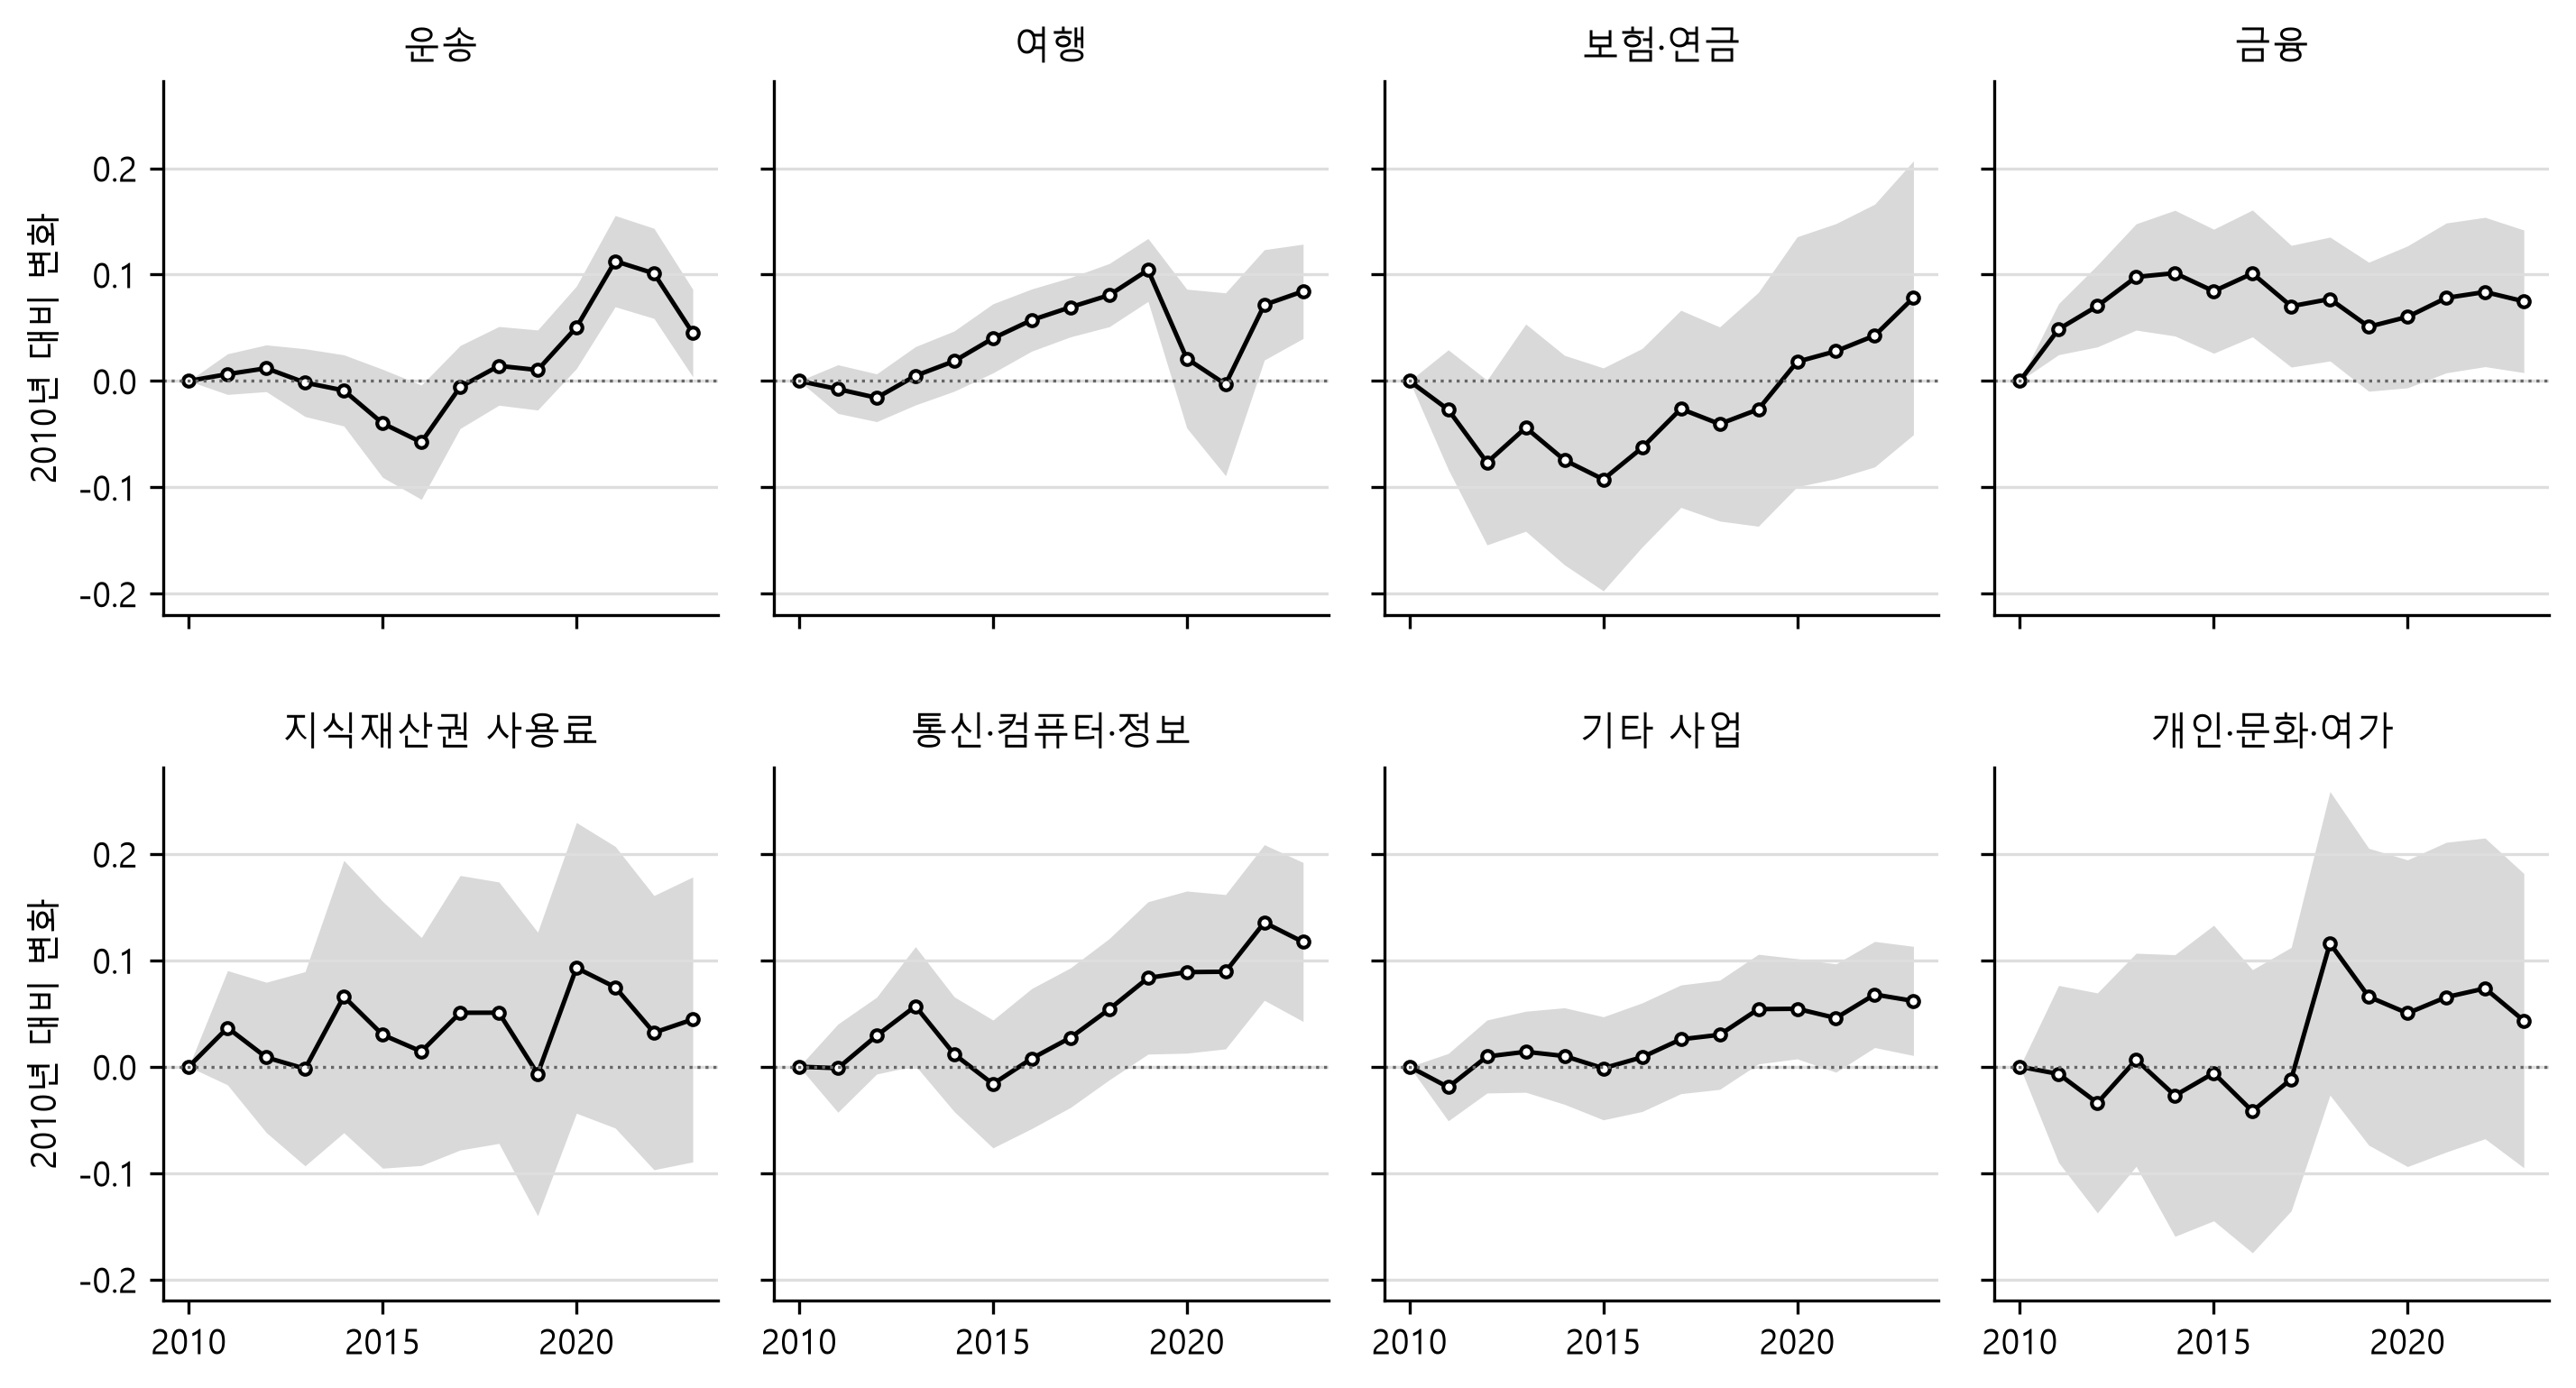

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(9.6, 5.2), sharex=True, sharey=True)
for ax, it in zip(axes.flat, ITEMS):
    ys = [Y0] + YRS
    b = np.array([0.0] + [S["year"][it][y]["b"] for y in YRS])
    se = np.array([0.0] + [S["year"][it][y]["se"] for y in YRS])
    ax.fill_between(ys, b - 1.96 * se, b + 1.96 * se, color="0.85", lw=0)
    ax.plot(ys, b, color="black", lw=1.2, marker="o", ms=3, mfc="white")
    ax.axhline(0, color="0.4", lw=0.8, ls=":")
    ax.set_title(NAME[it])
    ax.set_xticks([2010, 2015, 2020])
for ax in axes[:, 0]:
    ax.set_ylabel("2010년 대비 변화")
fig.tight_layout(h_pad=2.5)  # 윗단 가로축과 아랫단 제목이 붙지 않게
fig.savefig(IMG / "fig1_distance_by_year.png")
plt.close(fig)
display(Image(IMG / "fig1_distance_by_year.png", width=760))

## §6. 디지털 범주와 비교 범주의 추세 차이

IV.3절 표 4의 둘째 열이다(식 (5)). 디지털 범주 하나와 운송, 여행의 관측만 골라 부분표본을 만들고, 고정효과를 모두 범주와 교차시킨 채
운송과 여행에 공통인 추세에 디지털 범주 더미를 곱한 항을 더한다. 그 계수가 추세 차이다. 금융을 뺀 5개 디지털 범주와
6개 디지털 범주를 각각 묶어 공통의 추세 차이도 구한다.

In [11]:
S["trd_pool"] = {}
for it in DIGITAL:
    S["trd_pool"][it] = trd_diff(rv, it)
    print(NAME[it], {k: round(v, 4) for k, v in S["trd_pool"][it].items()}, flush=True)
S["trd_pool"]["DIG6"] = trd_diff(rv, DIGITAL)
S["trd_pool"]["DIG5"] = trd_diff(rv, [x for x in DIGITAL if x != "SG"])
print("묶음", S["trd_pool"]["DIG6"], S["trd_pool"]["DIG5"])

보험·연금 {'b': 0.0016, 'se': 0.0051, 'p': 0.7492, 'n': 132407}


금융 {'b': -0.0067, 'se': 0.0029, 'p': 0.0226, 'n': 135886}


지식재산권 사용료 {'b': -0.0048, 'se': 0.0052, 'p': 0.359, 'n': 133223}


통신·컴퓨터·정보 {'b': 0.0032, 'se': 0.0032, 'p': 0.3174, 'n': 143247}


기타 사업 {'b': -0.0017, 'se': 0.0021, 'p': 0.421, 'n': 146548}


개인·문화·여가 {'b': 0.0, 'se': 0.0048, 'p': 0.9922, 'n': 132299}


묶음 {'b': -0.002035029244517901, 'se': 0.0017108228036295493, 'p': 0.23424170219925067, 'n': 329380} {'b': -0.0009409865063350066, 'se': 0.0018192133070324653, 'p': 0.6049822575410637, 'n': 292340}


## §7. 추세의 강건성

V.2절 표 6이다. 값을 균형치로 바꾼 표본, 수출국과 수입국이 모두 보고한 관측, 2010\~2019년, 14년 모두 관측된 나라쌍,
중국·홍콩·마카오·대만 사이의 교역을 뺀 표본에서 식 (3)과 식 (5)를 다시 추정하고, 마지막 열은 표본을 그대로 두고
해마다 바뀌는 무역협정과 EU 동반 가입을 통제변수로 더한다.

In [12]:
# 표 6: A. 범주별 연간 추세, B. 비교 범주와의 추세 차이를 값, 표본, 통제변수를 바꾸어 다시 추정한다
COLS = {"bal": obs, "both": rv[rv.rx & rv.rm], "to2019": rv[rv.year <= 2019], "all14": rv[rv.nyr == 14],
        "ex_gchina": rv[~rv.gchina], "rta_eu": rv}
S["t6"], S["t6d"] = {}, {}
t0 = time.time()
for col, src in COLS.items():
    extra = " + rta_t + eu_both_t" if col == "rta_eu" else ""
    S["t6"][col] = {it: coef(ppml(src[src.item_code == it], "ld_t" + extra, "ey + iy + pair"), "ld_t") for it in ITEMS}
    S["t6d"][col] = {it: trd_diff(src, it, extra) for it in DIGITAL}
    S["t6d"][col]["DIG6"] = trd_diff(src, DIGITAL, extra)  # 6개 디지털 범주를 모두 묶은 추세 차이
    print(col, {it: round(S["t6"][col][it]["b"], 4) for it in ITEMS},
          {it: (round(S["t6d"][col][it]["b"], 4), round(S["t6d"][col][it]["p"], 3)) for it in DIGITAL + ["DIG6"]},
          f"{time.time() - t0:.0f}s", flush=True)

bal {'SC': 0.004, 'SD': 0.0042, 'SF': 0.0084, 'SG': -0.0044, 'SH': 0.0089, 'SI': 0.0075, 'SJ': 0.0032, 'SK': 0.0103} {'SF': (0.0043, 0.195), 'SG': (-0.0085, 0.001), 'SH': (0.0048, 0.371), 'SI': (0.0034, 0.164), 'SJ': (-0.0008, 0.618), 'SK': (0.0062, 0.124)} 1519s


both {'SC': 0.0055, 'SD': 0.0076, 'SF': 0.0147, 'SG': 0.0028, 'SH': 0.0035, 'SI': 0.0052, 'SJ': 0.0024, 'SK': 0.0008} {'SF': (0.0084, 0.144), 'SG': (-0.0036, 0.389), 'SH': (-0.0029, 0.644), 'SI': (-0.0012, 0.769), 'SJ': (-0.004, 0.195), 'SK': (-0.0055, 0.267)} 1678s


to2019 {'SC': -0.0003, 'SD': 0.0141, 'SF': 0.001, 'SG': 0.0021, 'SH': 0.0018, 'SI': 0.006, 'SJ': 0.0051, 'SK': 0.0105} {'SF': (-0.005, 0.412), 'SG': (-0.0039, 0.27), 'SH': (-0.0042, 0.557), 'SI': (0.0001, 0.99), 'SJ': (-0.0009, 0.796), 'SK': (0.0045, 0.548)} 2733s


all14 {'SC': 0.0069, 'SD': 0.0095, 'SF': 0.0065, 'SG': 0.002, 'SH': 0.001, 'SI': 0.009, 'SJ': 0.0035, 'SK': 0.0014} {'SF': (-0.0016, 0.785), 'SG': (-0.0061, 0.063), 'SH': (-0.0071, 0.231), 'SI': (0.0009, 0.834), 'SJ': (-0.0046, 0.273), 'SK': (-0.0067, 0.288)} 2859s


ex_gchina {'SC': 0.0064, 'SD': 0.0062, 'SF': 0.0094, 'SG': 0.0021, 'SH': 0.0031, 'SI': 0.0101, 'SJ': 0.0046, 'SK': 0.0053} {'SF': (0.003, 0.583), 'SG': (-0.0043, 0.153), 'SH': (-0.0032, 0.541), 'SI': (0.0038, 0.25), 'SJ': (-0.0017, 0.431), 'SK': (-0.001, 0.827)} 4111s


rta_eu {'SC': 0.0083, 'SD': 0.0062, 'SF': 0.0092, 'SG': -0.0009, 'SH': 0.0052, 'SI': 0.0116, 'SJ': 0.0057, 'SK': 0.0044} {'SF': (0.0008, 0.878), 'SG': (-0.008, 0.005), 'SH': (-0.0046, 0.375), 'SI': (0.0029, 0.367), 'SJ': (-0.0019, 0.349), 'SK': (-0.0003, 0.952)} 6729s


## §8. 본문 수치 검증

`paper.md`가 인용한 수치를 위에서 계산한 값과 하나씩 대조한다. 어긋나면 그 자리에서 멈춘다.

In [ ]:
import json as _dump_json
open(r"C:\Users\pilsu\AppData\Local\Temp\claude\C--Work-Projects-Services\4786ab90-3eb3-4930-8587-b10ff5ee3b03\scratchpad\S_dump.json", "w", encoding="utf-8").write(_dump_json.dumps(S, ensure_ascii=False, default=str))
print("S dumped")

In [13]:
# 산출값을 JSON으로 한 번 거쳐 연도 키를 문자열로 맞춘다. 본문과 같은 꼴로 읽기 위해서다.
S = json.loads(json.dumps(S, ensure_ascii=False))


def chk(name, got, want, tol=0.0006):
    ok = got is not None and abs(got - want) <= tol
    print(("OK  " if ok else "FAIL") + f" {name}: 계산 {got} / 본문 {want}")
    assert ok, f"{name}: 계산 {got} != 본문 {want}"


def ok(name, cond):
    print(("OK  " if cond else "FAIL") + f" {name}")
    assert cond, name


# III.1절 기간과 표본
chk("총서비스 관측 흐름 2009", S["S_obs_2009"], 1641, 0)
chk("총서비스 관측 흐름 2010", S["S_obs_2010"], 7481, 0)
chk("2010/2009 배율", r(S["S_obs_2010"] / S["S_obs_2009"], 1), 4.6, 0.01)
chk("2010 보고치 가운데 Eurostat ITS", S["S_2010_eu_its_share"], 81.7, 0.05)
# I장 디지털 서비스의 비중
chk("디지털 비중 2010", S["mix"]["2010"]["digital"], 46.5, 0.05)
chk("디지털 비중 2023", S["mix"]["2023"]["digital"], 54.7, 0.05)
chk("운송·여행 비중 2010", S["mix"]["2010"]["base"], 45.5, 0.05)
chk("운송·여행 비중 2023", S["mix"]["2023"]["base"], 38.3, 0.05)
chk("통신 비중 2010", S["mix"]["2010"]["SI"], 6.6, 0.05)
chk("통신 비중 2023", S["mix"]["2023"]["SI"], 10.7, 0.05)
# III.1절 여덟 범주의 합계 비중
chk("여덟 범주 비중 2010", r(S["mix"]["2010"]["digital"] + S["mix"]["2010"]["base"], 1), 92.0, 0.05)
chk("여덟 범주 비중 2023", r(S["mix"]["2023"]["digital"] + S["mix"]["2023"]["base"], 1), 93.0, 0.05)
chk("총서비스 관측 흐름 2024", S["S_obs_2024"], 2658, 0)
chk("총서비스 관측 흐름 2023", S["S_obs_2023"], 10987, 0)
chk("관측 흐름 행 비중", S["obs_rows_share"], 8.5, 0.05)
chk("관측 흐름 금액 비중", S["obs_value_share"], 74.7, 0.05)

# III.1절 보고표본의 규모(범위로 서술)
T1 = S["t1"]
chk("관측 수 최소", min(T1[it]["flows"] for it in ITEMS), 39207, 0)
chk("관측 수 최대", max(T1[it]["flows"] for it in ITEMS), 53780, 0)
chk("나라쌍 최소", min(T1[it]["pairs"] for it in ITEMS), 4212, 0)
chk("나라쌍 최대", max(T1[it]["pairs"] for it in ITEMS), 5975, 0)
chk("금액 비중 최소", min(T1[it]["val_cov"] for it in ITEMS), 65.3, 0.05)
chk("금액 비중 최대", max(T1[it]["val_cov"] for it in ITEMS), 86.2, 0.05)
chk("양쪽 보고 최소", min(T1[it]["both"] for it in ITEMS), 19.8, 0.05)
chk("양쪽 보고 최대", max(T1[it]["both"] for it in ITEMS), 27.9, 0.05)
chk("보고 경제 최소", min(S["t1"][it]["reporters"] for it in ITEMS), 51, 0)
chk("보고 경제 최대", max(S["t1"][it]["reporters"] for it in ITEMS), 58, 0)
chk("EU 보고 경제 최소", min(S["eu_reporters"].values()), 26, 0)
chk("EU 보고 경제 최대", max(S["eu_reporters"].values()), 27, 0)
ok("관측 흐름 범주별 4만~5만대", all(39000 <= S["t1"][it]["flows"] <= 54000 for it in ITEMS))

# III.2절 거리와 통제변수
chk("코소보 흐름 비중 최소", min(v["rows"] for v in S["xkv"].values()), 0.2, 0.05)
chk("코소보 흐름 비중 최대", max(v["rows"] for v in S["xkv"].values()), 1.3, 0.05)
ok("코소보 금액 비중 0.1% 미만", max(v["value"] for v in S["xkv"].values()) < 0.1)
ok("식민 관계 0으로 채운 흐름", S["col_fill_pairs"] == ["CHN-HKG", "CHN-TWN", "HKG-CHN", "TWN-CHN"])
chk("식민 관계 0 채운 금액 비중", S["col_fill_value_share"], 2.17, 0.005)
chk("공용어 결측으로 뺀 흐름", S["comlang_drop_obs_rows"], 260, 0)
ok("공용어 결측 금액 0.001% 미만", S["comlang_drop_obs_value_share"] < 0.001)

def star(pv):
    return "***" if pv < 0.01 else "**" if pv < 0.05 else "*" if pv < 0.1 else ""


def cell(name, got, want3):
    b, se, st = want3
    k = 4 if abs(b) < 0.05 and abs(se) < 0.01 else 3
    tol = 0.00006 if k == 4 else 0.0006
    chk(f"{name}", r(got["b"], k), b, tol)
    chk(f"{name} se", r(got["se"], k), se, tol)
    ok(f"{name} 별표 '{st}'", star(got["p"]) == st)


# 표 2(보고치 기준 식 (1))
T2V = {"SC": [[-0.615, 0.028, "***"], [0.169, 0.093, "*"], [0.236, 0.08, "***"], [0.228, 0.098, "**"], 53107, 5931], "SD": [[-0.919, 0.035, "***"], [0.395, 0.084, "***"], [0.521, 0.087, "***"], [0.271, 0.121, "**"], 47930, 5240], "SF": [[-0.649, 0.068, "***"], [-0.087, 0.211, ""], [0.651, 0.196, "***"], [-0.383, 0.282, ""], 39312, 3929], "SG": [[-0.566, 0.062, "***"], [0.062, 0.157, ""], [0.496, 0.118, "***"], [-0.12, 0.128, ""], 41975, 4213], "SH": [[-0.438, 0.071, "***"], [-0.216, 0.188, ""], [0.084, 0.162, ""], [-0.393, 0.19, "**"], 38351, 4006], "SI": [[-0.758, 0.035, "***"], [-0.184, 0.106, "*"], [0.147, 0.128, ""], [-0.224, 0.11, "**"], 46500, 5212], "SJ": [[-0.526, 0.029, "***"], [0.067, 0.097, ""], [0.513, 0.116, "***"], [-0.28, 0.107, "***"], 48918, 5459], "SK": [[-0.744, 0.051, "***"], [0.092, 0.134, ""], [0.495, 0.146, "***"], [0.106, 0.119, ""], 37518, 4335]}
for it, vals in T2V.items():
    for v, w in zip(("ldist", "contig", "comlang_off", "col_dep_ever"), vals[:4]):
        cell(f"표2 {it} {v}", S["t2"][it]["obs"][v], w)
    chk(f"표2 {it} 관측 수", S["t2"][it]["obs"]["ldist"]["n"], vals[4], 0)
    chk(f"표2 {it} 나라쌍", S["t2"][it]["pairs"], vals[5], 0)
B2 = {it: S["t2"][it]["obs"]["ldist"]["b"] for it in ITEMS}
ok("거리 탄력성 모두 1% 유의한 음수", all(S["t2"][it]["obs"]["ldist"]["p"] < 0.01 and B2[it] < 0 for it in ITEMS))
ok("여행의 절댓값이 가장 큼", min(B2, key=B2.get) == "SD")
chk("디지털 최대", r(max(B2[it] for it in DIGITAL)), -0.438)
chk("디지털 최소", r(min(B2[it] for it in DIGITAL)), -0.758)
ok("운송보다 절댓값 작은 디지털: 금융·지재·기타사업", sorted(it for it in DIGITAL if B2[it] > B2["SC"]) == ["SG", "SH", "SJ"])
CL = {it: S["t2"][it]["obs"]["comlang_off"]["b"] for it in ITEMS}
ok("공용어 모두 양수", all(v > 0 for v in CL.values()))
ok("공용어 0.49 이상: 여행·보험·금융·기타사업·개인", sorted(it for it in ITEMS if CL[it] >= 0.49) == ["SD", "SF", "SG", "SJ", "SK"])
CO = S
ok("식민 양수: 운송·여행·개인", all(S["t2"][it]["obs"]["col_dep_ever"]["b"] > 0 for it in ("SC", "SD", "SK")))
ok("식민 5% 유의한 음수: 지재·통신·기타사업",
   sorted(it for it in ITEMS if S["t2"][it]["obs"]["col_dep_ever"]["b"] < 0 and S["t2"][it]["obs"]["col_dep_ever"]["p"] < 0.05) == ["SH", "SI", "SJ"])

# 그림 1
S_Y = S["year"]
YV = {"SC": {"2014": -0.009, "2016": -0.058, "2019": 0.01, "2020": 0.05, "2021": 0.113, "2023": 0.045}, "SD": {"2014": 0.019, "2016": 0.057, "2019": 0.104, "2020": 0.021, "2021": -0.003, "2023": 0.084}, "SF": {"2014": -0.074, "2016": -0.063, "2019": -0.027, "2020": 0.018, "2021": 0.028, "2023": 0.078}, "SG": {"2014": 0.101, "2016": 0.101, "2019": 0.051, "2020": 0.06, "2021": 0.078, "2023": 0.075}, "SH": {"2014": 0.066, "2016": 0.014, "2019": -0.007, "2020": 0.093, "2021": 0.075, "2023": 0.044}, "SI": {"2014": 0.012, "2016": 0.008, "2019": 0.083, "2020": 0.089, "2021": 0.089, "2023": 0.117}, "SJ": {"2014": 0.01, "2016": 0.009, "2019": 0.054, "2020": 0.054, "2021": 0.046, "2023": 0.062}, "SK": {"2014": -0.027, "2016": -0.042, "2019": 0.066, "2020": 0.05, "2021": 0.065, "2023": 0.043}}
for it, d in YV.items():
    for y, w in d.items():
        if (it, y) in {("SI", "2019"), ("SC", "2016"), ("SC", "2019"), ("SC", "2021"), ("SC", "2023"), ("SD", "2019")}:
            chk(f"그림1 {it} {y}", r(S_Y[it][y]["b"]), w)
ok("2023년 계수 8개 범주 모두 양수", all(S_Y[it]["2023"]["b"] > 0 for it in ITEMS))
ok("여행 2020~2021년은 0 근처(0.03 안)", all(abs(S_Y["SD"][y]["b"]) < 0.03 for y in ("2020", "2021")))
ok("금융 2014년 0.1 근처, 이후 더 커지지 않음",
   abs(S_Y["SG"]["2014"]["b"] - 0.1) < 0.01 and max(S_Y["SG"][str(y)]["b"] for y in range(2015, 2024)) < S_Y["SG"]["2014"]["b"] + 0.005)

# 표 3
T3V = {"SC": [0.008, 0.0017, "***", 0.104, 52054, 5442], "SD": [0.0074, 0.0019, "***", 0.096, 46792, 4907], "SF": [0.0094, 0.0051, "*", 0.123, 33561, 3138], "SG": [0.0011, 0.0027, "", 0.014, 37040, 3416], "SH": [0.003, 0.0052, "", 0.039, 34377, 3204], "SI": [0.0109, 0.0031, "***", 0.142, 44401, 4609], "SJ": [0.0061, 0.0019, "***", 0.08, 47702, 5030], "SK": [0.0078, 0.0047, "*", 0.102, 33453, 3419]}
for it, (b, se, st, cum, n, pr) in T3V.items():
    cell(f"표3 {it} 추세", S["trend"][it], (b, se, st))
    chk(f"표3 {it} 누적", r(13 * S["trend"][it]["b"]), cum)
    chk(f"표3 {it} 관측 수", S["trend"][it]["n"], n, 0)
    chk(f"표3 {it} 나라쌍", S["trend"][it]["pairs"], pr, 0)
TR = S["trend"]
ok("추세 8개 범주 모두 양수", all(TR[it]["b"] > 0 for it in ITEMS))
ok("5% 유의: 운송·여행·통신·기타사업", sorted(it for it in ITEMS if TR[it]["p"] < 0.05) == ["SC", "SD", "SI", "SJ"])
ok("10%에서만: 보험·개인", sorted(it for it in ITEMS if 0.05 <= TR[it]["p"] < 0.1) == ["SF", "SK"])
chk("운송 누적/수준(%)", r(100 * 13 * TR["SC"]["b"] / abs(B2["SC"]), 0), 17, 0.5)
chk("여행 누적/수준(%)", r(100 * 13 * TR["SD"]["b"] / abs(B2["SD"]), 0), 10, 0.5)
chk("통신 추세/수준(%)", r(100 * TR["SI"]["b"] / abs(B2["SI"]), 1), 1.4, 0.05)
chk("통신 13년 누적(약 0.14)", r(13 * TR["SI"]["b"], 2), 0.14, 0.005)

# 표 4와 IV.3절
T4V = {"SF": [[0.093, 0.069, ""], [0.0016, 0.0051, ""]], "SG": [[0.176, 0.065, "***"], [-0.0067, 0.0029, "**"]], "SH": [[0.304, 0.073, "***"], [-0.0048, 0.0052, ""]], "SI": [[-0.017, 0.038, ""], [0.0032, 0.0032, ""]], "SJ": [[0.216, 0.034, "***"], [-0.0017, 0.0021, ""]], "SK": [[-0.003, 0.051, ""], [0.0, 0.0048, ""]]}
for it, (lv, tr) in T4V.items():
    cell(f"표4 수준 {it}", S["lvl_pool"][it], lv)
    cell(f"표4 추세 {it}", S["trd_pool"][it], tr)
LP, TP = S["lvl_pool"], S["trd_pool"]
ok("수준: 1% 유의하게 덜 민감한 범주는 금융·지재·기타사업", sorted(it for it in DIGITAL if LP[it]["b"] > 0 and LP[it]["p"] < 0.01) == ["SG", "SH", "SJ"])
ok("수준: 보험·통신·개인은 유의하지 않음", all(LP[it]["p"] > 0.1 for it in ("SF", "SI", "SK")))
ok("수준: 유의하게 더 민감한 범주 없음", not any(LP[it]["b"] < 0 and LP[it]["p"] < 0.1 for it in DIGITAL))
ok("추세: 유의하게 빠른 범주 없음", not any(TP[it]["b"] > 0 and TP[it]["p"] < 0.1 for it in DIGITAL))
chk("통신 추세 차이 p", r(TP["SI"]["p"]), 0.317)
chk("5개 묶음 추세 차이", r(TP["DIG5"]["b"], 4), -0.0009, 0.00006)
chk("5개 묶음 하한", r(TP["DIG5"]["b"] - 1.96 * TP["DIG5"]["se"], 4), -0.0045, 0.00006)
chk("5개 묶음 상한", r(TP["DIG5"]["b"] + 1.96 * TP["DIG5"]["se"], 4), 0.0026, 0.00006)
chk("6개 묶음 추세 차이", r(TP["DIG6"]["b"], 4), -0.0020, 0.00006)
ok("6개 묶음 유의하지 않음", TP["DIG6"]["p"] > 0.1)
chk("6개 묶음 표준오차", r(TP["DIG6"]["se"], 4), 0.0017, 0.00006)
chk("6개 묶음 하한", r(TP["DIG6"]["b"] - 1.96 * TP["DIG6"]["se"], 4), -0.0054, 0.00006)
chk("6개 묶음 상한", r(TP["DIG6"]["b"] + 1.96 * TP["DIG6"]["se"], 4), 0.0013, 0.00006)
ok("6개 묶음 상한은 비교 범주 추세의 약 6분의 1", 0.14 <= (TP["DIG6"]["b"] + 1.96 * TP["DIG6"]["se"]) / ((TR["SC"]["b"] + TR["SD"]["b"]) / 2) <= 0.20)
chk("범주별 추세 차이 표준오차 최소", r(min(TP[it]["se"] for it in DIGITAL), 4), 0.0021, 0.00006)
chk("범주별 추세 차이 표준오차 최대", r(max(TP[it]["se"] for it in DIGITAL), 4), 0.0052, 0.00006)
ok("5개 묶음 상한은 비교 범주 추세의 약 3분의 1", 0.30 <= (TP["DIG5"]["b"] + 1.96 * TP["DIG5"]["se"]) / ((TR["SC"]["b"] + TR["SD"]["b"]) / 2) <= 0.37)
ok("비교 범주 추세 약 0.008", 0.0075 <= (TR["SC"]["b"] + TR["SD"]["b"]) / 2 <= 0.0080)

# 표 5와 V.1절
T5V = {"SC": [[-0.591, 0.023, "***"], [-0.599, 0.028, "***"], [-0.618, 0.028, "***"], [-0.581, 0.033, "***"], [-0.563, 0.035, "***"]], "SD": [[-0.847, 0.031, "***"], [-0.8, 0.041, "***"], [-0.826, 0.04, "***"], [-0.848, 0.039, "***"], [-0.867, 0.043, "***"]], "SF": [[-0.682, 0.056, "***"], [-0.569, 0.069, "***"], [-0.579, 0.069, "***"], [-0.559, 0.073, "***"], [-0.592, 0.087, "***"]], "SG": [[-0.582, 0.055, "***"], [-0.511, 0.057, "***"], [-0.522, 0.058, "***"], [-0.517, 0.061, "***"], [-0.54, 0.071, "***"]], "SH": [[-0.404, 0.075, "***"], [-0.428, 0.063, "***"], [-0.44, 0.066, "***"], [-0.358, 0.067, "***"], [-0.347, 0.068, "***"]], "SI": [[-0.681, 0.029, "***"], [-0.714, 0.034, "***"], [-0.73, 0.035, "***"], [-0.672, 0.033, "***"], [-0.622, 0.04, "***"]], "SJ": [[-0.539, 0.026, "***"], [-0.506, 0.028, "***"], [-0.515, 0.029, "***"], [-0.481, 0.038, "***"], [-0.463, 0.035, "***"]], "SK": [[-0.708, 0.041, "***"], [-0.671, 0.057, "***"], [-0.695, 0.056, "***"], [-0.687, 0.056, "***"], [-0.658, 0.06, "***"]]}
for it, cols in T5V.items():
    cell(f"표5 {it} 기준", S["t2"][it]["obs"]["ldist"], T2V[it][0])
    for k, w in zip(("bal", "dist", "distcap", "eu", "li"), cols):
        cell(f"표5 {it} {k}", S["t5"][it][k], w)
for k in ("bal", "dist", "distcap", "eu", "li"):
    v = {it: S["t5"][it][k]["b"] for it in ITEMS}
    ok(f"표5 {k}: 1% 유의한 음수", all(S["t5"][it][k]["p"] < 0.01 and v[it] < 0 for it in ITEMS))
    ok(f"표5 {k}: 여행 최대, 지재 최소, 통신이 운송보다 큼", min(v, key=v.get) == "SD" and max(v, key=v.get) == "SH" and v["SI"] < v["SC"])
red = [abs(B2[it]) - abs(S["t5"][it]["eu"]["b"]) for it in ITEMS]
chk("EU 추가 감소 최소", r(min(red), 2), 0.03, 0.005)
chk("EU 추가 감소 최대", r(max(red), 2), 0.09, 0.005)
ok("Li 조합으로 절댓값이 8개 범주 모두 작아짐", all(abs(S["t5"][it]["li"]["b"]) < abs(B2[it]) for it in ITEMS))
LPL = S["li_pool"]
for it, w in {"SG": 0.147, "SH": 0.340, "SJ": 0.224}.items():
    chk(f"Li 조합 수준 차이 {it}", r(LPL[it]["b"]), w)
ok("Li 조합: 5% 유의한 범주는 금융·지재·기타사업", sorted(it for it in DIGITAL if LPL[it]["p"] < 0.05) == ["SG", "SH", "SJ"])

# 표 6과 V.2절
T6V = {"SC": [[0.004, 0.0014, "***"], [0.0055, 0.0027, "**"], [-0.0003, 0.0022, ""], [0.0069, 0.0026, "***"], [0.0064, 0.0018, "***"], [0.0083, 0.0018, "***"]], "SD": [[0.0042, 0.0015, "***"], [0.0076, 0.0018, "***"], [0.0141, 0.0018, "***"], [0.0095, 0.0025, "***"], [0.0062, 0.002, "***"], [0.0062, 0.0021, "***"]], "SF": [[0.0084, 0.0032, "***"], [0.0147, 0.0055, "***"], [0.001, 0.0063, ""], [0.0065, 0.0056, ""], [0.0094, 0.0054, "*"], [0.0092, 0.0051, "*"]], "SG": [[-0.0044, 0.0025, "*"], [0.0028, 0.0038, ""], [0.0021, 0.0033, ""], [0.002, 0.0029, ""], [0.0021, 0.0028, ""], [-0.0009, 0.0026, ""]], "SH": [[0.0089, 0.0053, "*"], [0.0035, 0.0061, ""], [0.0018, 0.007, ""], [0.001, 0.0057, ""], [0.0031, 0.0052, ""], [0.0052, 0.0049, ""]], "SI": [[0.0075, 0.0023, "***"], [0.0052, 0.0037, ""], [0.006, 0.0044, ""], [0.009, 0.004, "**"], [0.0101, 0.0031, "***"], [0.0116, 0.0031, "***"]], "SJ": [[0.0032, 0.0015, "**"], [0.0024, 0.0027, ""], [0.0051, 0.003, "*"], [0.0035, 0.0041, ""], [0.0046, 0.0019, "**"], [0.0057, 0.002, "***"]], "SK": [[0.0103, 0.0039, "***"], [0.0008, 0.0046, ""], [0.0105, 0.0074, ""], [0.0014, 0.0061, ""], [0.0053, 0.0047, ""], [0.0044, 0.0052, ""]]}
T6D = {"SF": [[0.0043, 0.0033, ""], [0.0084, 0.0057, ""], [-0.005, 0.0061, ""], [-0.0016, 0.0059, ""], [0.003, 0.0055, ""], [0.0008, 0.0051, ""]], "SG": [[-0.0085, 0.0025, "***"], [-0.0036, 0.0042, ""], [-0.0039, 0.0036, ""], [-0.0061, 0.0033, "*"], [-0.0043, 0.003, ""], [-0.008, 0.0028, "***"]], "SH": [[0.0048, 0.0054, ""], [-0.0029, 0.0064, ""], [-0.0042, 0.0071, ""], [-0.0071, 0.0059, ""], [-0.0032, 0.0052, ""], [-0.0046, 0.0052, ""]], "SI": [[0.0034, 0.0025, ""], [-0.0012, 0.004, ""], [0.0001, 0.0046, ""], [0.0009, 0.0042, ""], [0.0038, 0.0033, ""], [0.0029, 0.0032, ""]], "SJ": [[-0.0008, 0.0017, ""], [-0.004, 0.0031, ""], [-0.0009, 0.0034, ""], [-0.0046, 0.0042, ""], [-0.0017, 0.0022, ""], [-0.0019, 0.0021, ""]], "SK": [[0.0062, 0.004, ""], [-0.0055, 0.005, ""], [0.0045, 0.0074, ""], [-0.0067, 0.0063, ""], [-0.001, 0.0048, ""], [-0.0003, 0.0048, ""]]}
C6 = ("bal", "both", "to2019", "all14", "ex_gchina", "rta_eu")
for it, cols in T6V.items():
    for k, w in zip(C6, cols):
        cell(f"표6 A {it} {k}", S["t6"][k][it], w)
for it, cols in T6D.items():
    for k, w in zip(C6, cols):
        cell(f"표6 B {it} {k}", S["t6d"][k][it], w)
ok("균형치에서 운송·여행 추세는 기준의 절반 안팎", all(0.4 <= S["t6"]["bal"][it]["b"] / TR[it]["b"] <= 0.65 for it in ("SC", "SD")))
ok("14년 모두: 운송·여행·통신 5% 유의", all(S["t6"]["all14"][it]["p"] < 0.05 for it in ("SC", "SD", "SI")))
ok("패널 B: 유의하게 빠른 범주 없음", not any(S["t6d"][k][it]["b"] > 0 and S["t6d"][k][it]["p"] < 0.1 for k in C6 for it in DIGITAL))
ok("패널 B: 디지털 6개 전체도 어느 열에서나 유의하게 빠르지 않음", not any(S["t6d"][k]["DIG6"]["b"] > 0 and S["t6d"][k]["DIG6"]["p"] < 0.1 for k in C6))
ok("금융 추세 차이: 균형치·14년·무역협정에서 유의한 음수", all(S["t6d"][k]["SG"]["b"] < 0 and S["t6d"][k]["SG"]["p"] < 0.1 for k in ("bal", "all14", "rta_eu")))
ok("금융 추세 차이: 양쪽 보고·2010~2019·중화권 제외에서 유의하지 않음", all(S["t6d"][k]["SG"]["p"] >= 0.1 for k in ("both", "to2019", "ex_gchina")))

print("본문 수치 검증 통과")


OK   총서비스 관측 흐름 2009: 계산 1641 / 본문 1641
OK   총서비스 관측 흐름 2010: 계산 7481 / 본문 7481
OK   2010/2009 배율: 계산 4.6 / 본문 4.6
OK   2010 보고치 가운데 Eurostat ITS: 계산 81.7 / 본문 81.7
OK   디지털 비중 2010: 계산 46.5 / 본문 46.5
OK   디지털 비중 2023: 계산 54.7 / 본문 54.7
OK   운송·여행 비중 2010: 계산 45.5 / 본문 45.5
OK   운송·여행 비중 2023: 계산 38.3 / 본문 38.3
OK   통신 비중 2010: 계산 6.6 / 본문 6.6
OK   통신 비중 2023: 계산 10.7 / 본문 10.7
OK   여덟 범주 비중 2010: 계산 92.0 / 본문 92.0
OK   여덟 범주 비중 2023: 계산 93.0 / 본문 93.0
OK   총서비스 관측 흐름 2024: 계산 2658 / 본문 2658
OK   총서비스 관측 흐름 2023: 계산 10987 / 본문 10987
OK   관측 흐름 행 비중: 계산 8.5 / 본문 8.5
OK   관측 흐름 금액 비중: 계산 74.7 / 본문 74.7
OK   관측 수 최소: 계산 39207 / 본문 39207
OK   관측 수 최대: 계산 53780 / 본문 53780
OK   나라쌍 최소: 계산 4212 / 본문 4212
OK   나라쌍 최대: 계산 5975 / 본문 5975
OK   금액 비중 최소: 계산 65.3 / 본문 65.3
OK   금액 비중 최대: 계산 86.2 / 본문 86.2
OK   양쪽 보고 최소: 계산 19.8 / 본문 19.8
OK   양쪽 보고 최대: 계산 27.9 / 본문 27.9
OK   보고 경제 최소: 계산 51 / 본문 51
OK   보고 경제 최대: 계산 58 / 본문 58
OK   EU 보고 경제 최소: 계산 26 / 본문 26
OK   EU 보고 경제 최대: 계산 27 / 본문 27
OK   관측 